In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Adjust this to change how many weights are generated in each distribution.
NUM_WEIGHTS = 100
RNG_SEED = 7
LOW_ESS_DOMINANT_COUNT = 5
ESS_SWEEP_STEPS = 40


def normalize(weights: np.ndarray) -> np.ndarray:
    """Normalize a non-negative weight array so it sums to 1."""
    total = np.sum(weights)
    if total <= 0:
        raise ValueError("Weights must have a positive sum")
    return weights / total


def effective_sample_size(weights: np.ndarray) -> float:
    """ESS = 1 / sum(w_i^2), assuming normalized weights."""
    w = normalize(weights)
    return 1.0 / np.sum(np.square(w))

In [3]:
rng = np.random.default_rng(RNG_SEED)

# Low ESS: a few randomly chosen particles get much larger weights.
low_raw = np.full(NUM_WEIGHTS, 1e-3, dtype=float)
dominant_idx = rng.choice(NUM_WEIGHTS, size=LOW_ESS_DOMINANT_COUNT, replace=False)

x = np.arange(NUM_WEIGHTS)
for idx in dominant_idx:
    sigma = rng.uniform(1.2, 2.5)      # slight spread
    amplitude = rng.uniform(0.8, 1.6)  # dominant peak strength

    # Circular distance so peaks near edges still look Gaussian.
    d = np.abs(x - idx)
    d = np.minimum(d, NUM_WEIGHTS - d)

    low_raw += amplitude * np.exp(-0.5 * (d / sigma) ** 2)

low_weights = normalize(low_raw)

# High ESS: close to uniform, with mild random variation.
high_raw = rng.uniform(0.9, 1.1, size=NUM_WEIGHTS)
high_weights = normalize(high_raw)

low_ess = effective_sample_size(low_weights)
high_ess = effective_sample_size(high_weights)


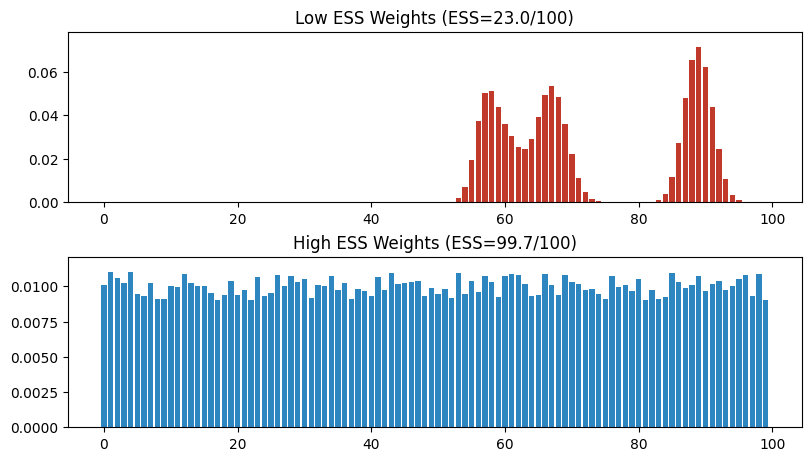

Low ESS  = 23.04 out of 100
High ESS = 99.66 out of 100


In [5]:

x = np.arange(NUM_WEIGHTS)

fig, axes = plt.subplots(2, 1, figsize=(8, 4.5), constrained_layout=True)

axes[0].bar(x, low_weights, color="#c0392b")
axes[0].set_title(f"Low ESS Weights (ESS={low_ess:.1f}/{NUM_WEIGHTS})")
# axes[0].set_xlabel("Index")
axes[0].set_ylim(0, max(low_weights) * 1.1)

axes[1].bar(x, high_weights, color="#2e86c1")
axes[1].set_title(f"High ESS Weights (ESS={high_ess:.1f}/{NUM_WEIGHTS})")
# axes[1].set_xlabel("Index")
axes[1].set_ylim(0, max(high_weights) * 1.1)

plt.show()

print(f"Low ESS  = {low_ess:.2f} out of {NUM_WEIGHTS}")
print(f"High ESS = {high_ess:.2f} out of {NUM_WEIGHTS}")

In [6]:
# Verify that normalized weights sum to 1
print("Low weights sum:", np.sum(low_weights))
print("High weights sum:", np.sum(high_weights))

Low weights sum: 1.0000000000000002
High weights sum: 1.0


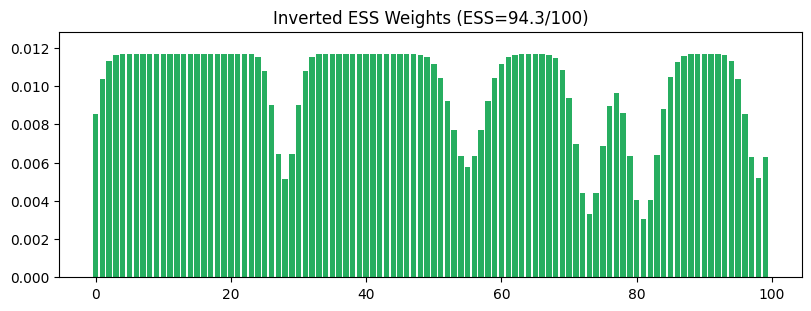

Inverted ESS = 94.34 out of 100


In [7]:
# High ESS with Gaussian clumps of low weights
inverted_raw = np.full(NUM_WEIGHTS, 1.0, dtype=float)

# Create clumps of low weights at random locations
clump_idx = rng.choice(NUM_WEIGHTS, size=LOW_ESS_DOMINANT_COUNT, replace=False)

for idx in clump_idx:
    sigma = rng.uniform(1.2, 2.5)
    amplitude = rng.uniform(0.5, 0.8)  # reduce from baseline
    
    d = np.abs(x - idx)
    d = np.minimum(d, NUM_WEIGHTS - d)
    
    inverted_raw -= amplitude * np.exp(-0.5 * (d / sigma) ** 2)

inverted_raw = np.maximum(inverted_raw, 1e-3)  # ensure positive
inverted_weights = normalize(inverted_raw)
inverted_ess = effective_sample_size(inverted_weights)

fig, axes = plt.subplots(1, 1, figsize=(8, 3), constrained_layout=True)

axes.bar(x, inverted_weights, color="#27ae60")
axes.set_title(f"Inverted ESS Weights (ESS={inverted_ess:.1f}/{NUM_WEIGHTS})")
axes.set_ylim(0, max(inverted_weights) * 1.1)

plt.show()

print(f"Inverted ESS = {inverted_ess:.2f} out of {NUM_WEIGHTS}")

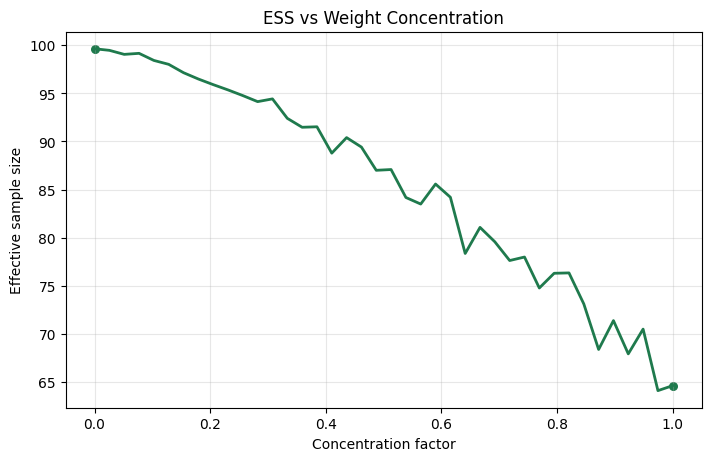

Sweep ESS range: 64.11 to 99.64


In [12]:
# ESS vs concentration: reuse the same sample size but increasingly concentrate weights.
concentration = np.linspace(0.0, 1.0, ESS_SWEEP_STEPS)
ess_curve = []

for c in concentration:
    base = rng.uniform(0.9, 1.1, size=NUM_WEIGHTS)
    concentrated = np.power(base, 1.0 + 12.0 * c)
    ess_curve.append(effective_sample_size(concentrated))

ess_curve = np.array(ess_curve)

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.plot(concentration, ess_curve, color="#1f7a4d", lw=2)
ax.scatter([0.0, 1.0], [ess_curve[0], ess_curve[-1]], color="#1f7a4d", s=30)
ax.set_title("ESS vs Weight Concentration")
ax.set_xlabel("Concentration factor")
ax.set_ylabel("Effective sample size")
ax.grid(alpha=0.3)

plt.show()

print(f"Sweep ESS range: {ess_curve.min():.2f} to {ess_curve.max():.2f}")

In [5]:
from pathlib import Path
import sys

# Make the robot package modules importable from this notebook location.
robot_root = (Path.cwd().resolve() / "../robot").resolve()
if str(robot_root) not in sys.path:
    sys.path.append(str(robot_root))

from common.poses import Poses
from common import arena
from observation_models.boundary import BoundaryObservationModel

HYPOTHETICAL_POSE_COUNT = NUM_WEIGHTS
boundary_model = BoundaryObservationModel()

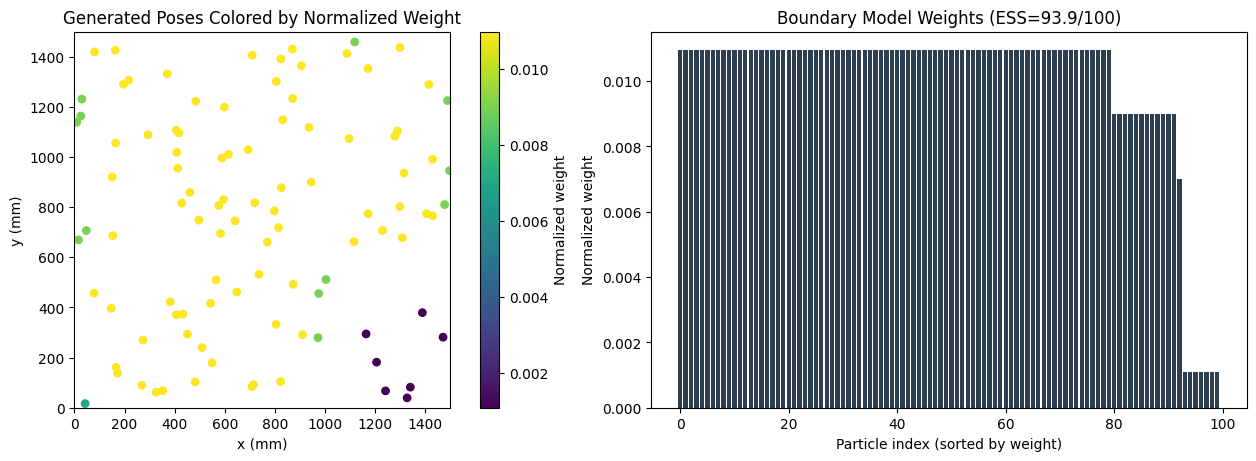

Hypothetical boundary-model ESS = 93.89 out of 100


In [6]:
hypothetical_poses = Poses.generate(
    HYPOTHETICAL_POSE_COUNT,
    (arena.left, arena.right),
    (arena.bottom, arena.top),
    (0, 2 * np.pi),
)

raw_weights = boundary_model.calculate_weights(hypothetical_poses)
normalized_weights = normalize(raw_weights)
hypothetical_ess = effective_sample_size(normalized_weights)

indices = np.arange(HYPOTHETICAL_POSE_COUNT)
sorted_weights = np.sort(normalized_weights)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

scatter = axes[0].scatter(
    hypothetical_poses['x'],
    hypothetical_poses['y'],
    c=normalized_weights,
    cmap="viridis",
    s=28,
)
axes[0].set_title("Generated Poses Colored by Normalized Weight")
axes[0].set_xlabel("x (mm)")
axes[0].set_ylabel("y (mm)")
axes[0].set_xlim(arena.left, arena.right)
axes[0].set_ylim(arena.bottom, arena.top)
axes[0].set_aspect("equal", adjustable="box")
fig.colorbar(scatter, ax=axes[0], label="Normalized weight")

axes[1].bar(indices, sorted_weights, color="#2c3e50")
axes[1].set_title(
    f"Boundary Model Weights (ESS={hypothetical_ess:.1f}/{HYPOTHETICAL_POSE_COUNT})"
)
axes[1].set_xlabel("Particle index (sorted by weight)")
axes[1].set_ylabel("Normalized weight")

plt.show()

print(f"Hypothetical boundary-model ESS = {hypothetical_ess:.2f} out of {HYPOTHETICAL_POSE_COUNT}")

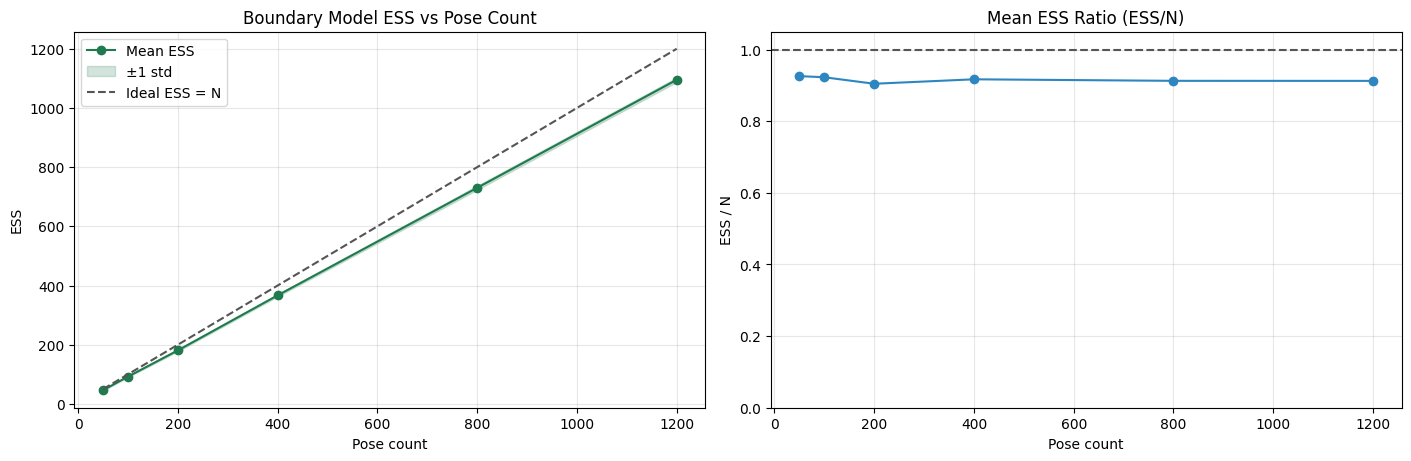

Pose count | Mean ESS | Std ESS | Mean ESS/N
        50 |    46.29 |    1.51 |      0.926
       100 |    92.27 |    2.02 |      0.923
       200 |   180.91 |    3.20 |      0.905
       400 |   366.79 |    3.87 |      0.917
       800 |   730.18 |    6.74 |      0.913
      1200 |  1095.08 |    7.49 |      0.913


In [7]:
POSE_COUNT_SWEEP = np.array([50, 100, 200, 400, 800, 1200])
TRIALS_PER_COUNT = 25

ess_means = []
ess_stds = []
ess_ratio_means = []

for pose_count in POSE_COUNT_SWEEP:
    trial_ess = []
    for _ in range(TRIALS_PER_COUNT):
        poses = Poses.generate(
            pose_count,
            (arena.left, arena.right),
            (arena.bottom, arena.top),
            (0, 2 * np.pi),
        )
        weights = normalize(boundary_model.calculate_weights(poses))
        trial_ess.append(effective_sample_size(weights))

    trial_ess = np.array(trial_ess)
    ess_means.append(trial_ess.mean())
    ess_stds.append(trial_ess.std())
    ess_ratio_means.append((trial_ess / pose_count).mean())

ess_means = np.array(ess_means)
ess_stds = np.array(ess_stds)
ess_ratio_means = np.array(ess_ratio_means)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].plot(POSE_COUNT_SWEEP, ess_means, marker="o", color="#1f7a4d", label="Mean ESS")
axes[0].fill_between(
    POSE_COUNT_SWEEP,
    ess_means - ess_stds,
    ess_means + ess_stds,
    color="#1f7a4d",
    alpha=0.2,
    label="±1 std",
)
axes[0].plot(POSE_COUNT_SWEEP, POSE_COUNT_SWEEP, "--", color="#555555", label="Ideal ESS = N")
axes[0].set_title("Boundary Model ESS vs Pose Count")
axes[0].set_xlabel("Pose count")
axes[0].set_ylabel("ESS")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(POSE_COUNT_SWEEP, ess_ratio_means, marker="o", color="#2e86c1")
axes[1].axhline(1.0, linestyle="--", color="#555555")
axes[1].set_title("Mean ESS Ratio (ESS/N)")
axes[1].set_xlabel("Pose count")
axes[1].set_ylabel("ESS / N")
axes[1].set_ylim(0.0, 1.05)
axes[1].grid(alpha=0.3)

plt.show()

print("Pose count | Mean ESS | Std ESS | Mean ESS/N")
for pose_count, mean_ess, std_ess, ratio in zip(
    POSE_COUNT_SWEEP, ess_means, ess_stds, ess_ratio_means
):
    print(f"{pose_count:10d} | {mean_ess:8.2f} | {std_ess:7.2f} | {ratio:10.3f}")

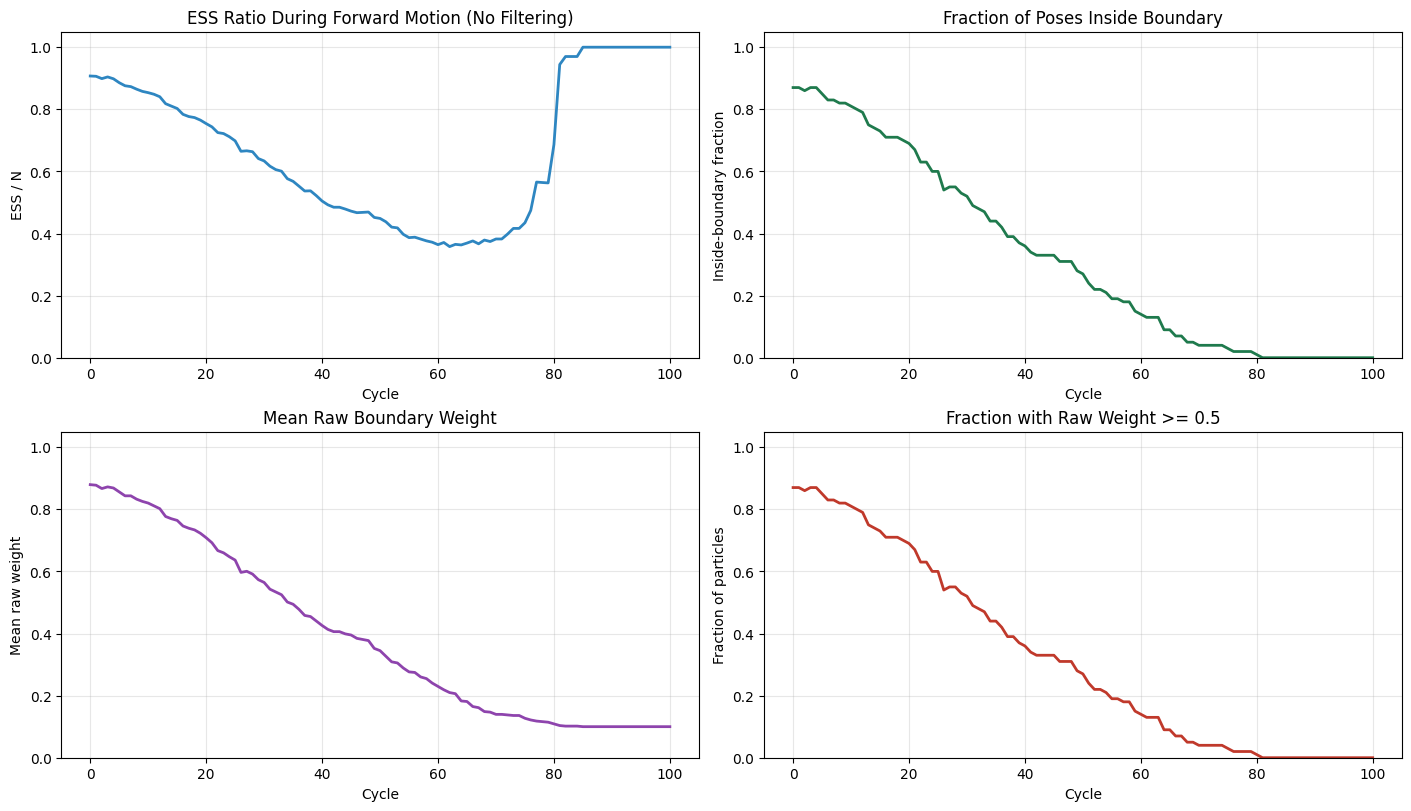

Start ESS ratio:            0.907
End ESS ratio:              1.000
Min ESS ratio:              0.358
Start mean raw weight:      0.879
End mean raw weight:        0.100
End high-weight fraction:   0.000


In [9]:
FORWARD_CYCLES = 100
FORWARD_STEP_MM = 20.0
FORWARD_ROTATION_RAD = 0.0
RAW_WEIGHT_THRESHOLD = 0.5

iterative_poses = Poses.generate(
    HYPOTHETICAL_POSE_COUNT,
    (arena.left, arena.right),
    (arena.bottom, arena.top),
    (0, 2 * np.pi),
)

cycle_index = np.arange(FORWARD_CYCLES + 1)
ess_values = []
ess_ratio_values = []
inside_ratio_values = []
mean_raw_weight_values = []
high_raw_fraction_values = []

for _ in cycle_index:
    raw_weights = boundary_model.calculate_weights(iterative_poses)
    current_weights = normalize(raw_weights)
    current_ess = effective_sample_size(current_weights)

    ess_values.append(current_ess)
    ess_ratio_values.append(current_ess / HYPOTHETICAL_POSE_COUNT)

    inside_flags = boundary_model.in_boundary(iterative_poses)
    inside_ratio_values.append(np.mean(inside_flags))

    mean_raw_weight_values.append(np.mean(raw_weights))
    high_raw_fraction_values.append(np.mean(raw_weights >= RAW_WEIGHT_THRESHOLD))

    iterative_poses = iterative_poses.move(FORWARD_ROTATION_RAD, FORWARD_STEP_MM)

ess_values = np.array(ess_values)
ess_ratio_values = np.array(ess_ratio_values)
inside_ratio_values = np.array(inside_ratio_values)
mean_raw_weight_values = np.array(mean_raw_weight_values)
high_raw_fraction_values = np.array(high_raw_fraction_values)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

axes[0, 0].plot(cycle_index, ess_ratio_values, color="#2e86c1", lw=2)
axes[0, 0].set_title("ESS Ratio During Forward Motion (No Filtering)")
axes[0, 0].set_xlabel("Cycle")
axes[0, 0].set_ylabel("ESS / N")
axes[0, 0].set_ylim(0.0, 1.05)
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(cycle_index, inside_ratio_values, color="#1f7a4d", lw=2)
axes[0, 1].set_title("Fraction of Poses Inside Boundary")
axes[0, 1].set_xlabel("Cycle")
axes[0, 1].set_ylabel("Inside-boundary fraction")
axes[0, 1].set_ylim(0.0, 1.05)
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(cycle_index, mean_raw_weight_values, color="#8e44ad", lw=2)
axes[1, 0].set_title("Mean Raw Boundary Weight")
axes[1, 0].set_xlabel("Cycle")
axes[1, 0].set_ylabel("Mean raw weight")
axes[1, 0].set_ylim(0.0, 1.05)
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(cycle_index, high_raw_fraction_values, color="#c0392b", lw=2)
axes[1, 1].set_title(f"Fraction with Raw Weight >= {RAW_WEIGHT_THRESHOLD:.1f}")
axes[1, 1].set_xlabel("Cycle")
axes[1, 1].set_ylabel("Fraction of particles")
axes[1, 1].set_ylim(0.0, 1.05)
axes[1, 1].grid(alpha=0.3)

plt.show()

print(f"Start ESS ratio:            {ess_ratio_values[0]:.3f}")
print(f"End ESS ratio:              {ess_ratio_values[-1]:.3f}")
print(f"Min ESS ratio:              {ess_ratio_values.min():.3f}")
print(f"Start mean raw weight:      {mean_raw_weight_values[0]:.3f}")
print(f"End mean raw weight:        {mean_raw_weight_values[-1]:.3f}")
print(f"End high-weight fraction:   {high_raw_fraction_values[-1]:.3f}")

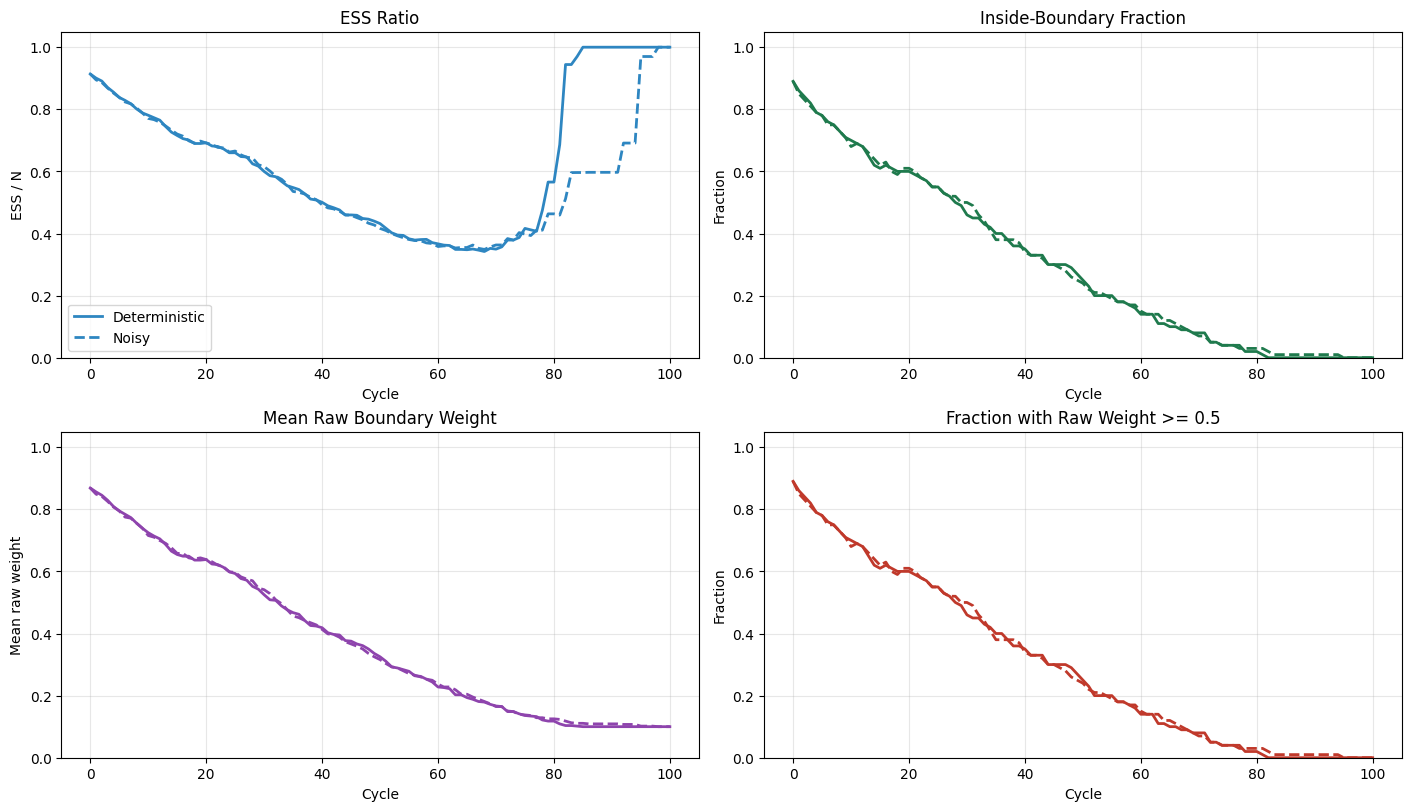

End-of-run comparison
ESS ratio:   deterministic=1.000, noisy=1.000
Mean raw:    deterministic=0.100, noisy=0.100
High-frac:   deterministic=0.000, noisy=0.000


In [10]:
NOISE_STD_TRANS_MM = 2.0
NOISE_STD_ROT_RAD = 0.01


def run_forward_metrics(initial_poses, noisy_motion=False):
    poses = initial_poses.copy()

    ess_ratio = []
    inside_ratio = []
    mean_raw = []
    high_raw_fraction = []

    for _ in cycle_index:
        raw = boundary_model.calculate_weights(poses)
        norm = normalize(raw)

        ess_ratio.append(effective_sample_size(norm) / HYPOTHETICAL_POSE_COUNT)
        inside_ratio.append(np.mean(boundary_model.in_boundary(poses)))
        mean_raw.append(np.mean(raw))
        high_raw_fraction.append(np.mean(raw >= RAW_WEIGHT_THRESHOLD))

        if noisy_motion:
            rot = FORWARD_ROTATION_RAD + np.random.normal(0.0, NOISE_STD_ROT_RAD, HYPOTHETICAL_POSE_COUNT)
            trans = FORWARD_STEP_MM + np.random.normal(0.0, NOISE_STD_TRANS_MM, HYPOTHETICAL_POSE_COUNT)
        else:
            rot = FORWARD_ROTATION_RAD
            trans = FORWARD_STEP_MM

        poses = poses.move(rot, trans)

    return {
        "ess_ratio": np.array(ess_ratio),
        "inside_ratio": np.array(inside_ratio),
        "mean_raw": np.array(mean_raw),
        "high_raw_fraction": np.array(high_raw_fraction),
    }


base_poses = Poses.generate(
    HYPOTHETICAL_POSE_COUNT,
    (arena.left, arena.right),
    (arena.bottom, arena.top),
    (0, 2 * np.pi),
)

det_metrics = run_forward_metrics(base_poses, noisy_motion=False)
noisy_metrics = run_forward_metrics(base_poses, noisy_motion=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

axes[0, 0].plot(cycle_index, det_metrics["ess_ratio"], color="#2e86c1", lw=2, label="Deterministic")
axes[0, 0].plot(cycle_index, noisy_metrics["ess_ratio"], color="#2e86c1", lw=2, ls="--", label="Noisy")
axes[0, 0].set_title("ESS Ratio")
axes[0, 0].set_xlabel("Cycle")
axes[0, 0].set_ylabel("ESS / N")
axes[0, 0].set_ylim(0.0, 1.05)
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(cycle_index, det_metrics["inside_ratio"], color="#1f7a4d", lw=2)
axes[0, 1].plot(cycle_index, noisy_metrics["inside_ratio"], color="#1f7a4d", lw=2, ls="--")
axes[0, 1].set_title("Inside-Boundary Fraction")
axes[0, 1].set_xlabel("Cycle")
axes[0, 1].set_ylabel("Fraction")
axes[0, 1].set_ylim(0.0, 1.05)
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(cycle_index, det_metrics["mean_raw"], color="#8e44ad", lw=2)
axes[1, 0].plot(cycle_index, noisy_metrics["mean_raw"], color="#8e44ad", lw=2, ls="--")
axes[1, 0].set_title("Mean Raw Boundary Weight")
axes[1, 0].set_xlabel("Cycle")
axes[1, 0].set_ylabel("Mean raw weight")
axes[1, 0].set_ylim(0.0, 1.05)
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(cycle_index, det_metrics["high_raw_fraction"], color="#c0392b", lw=2)
axes[1, 1].plot(cycle_index, noisy_metrics["high_raw_fraction"], color="#c0392b", lw=2, ls="--")
axes[1, 1].set_title(f"Fraction with Raw Weight >= {RAW_WEIGHT_THRESHOLD:.1f}")
axes[1, 1].set_xlabel("Cycle")
axes[1, 1].set_ylabel("Fraction")
axes[1, 1].set_ylim(0.0, 1.05)
axes[1, 1].grid(alpha=0.3)

plt.show()

print("End-of-run comparison")
print(f"ESS ratio:   deterministic={det_metrics['ess_ratio'][-1]:.3f}, noisy={noisy_metrics['ess_ratio'][-1]:.3f}")
print(f"Mean raw:    deterministic={det_metrics['mean_raw'][-1]:.3f}, noisy={noisy_metrics['mean_raw'][-1]:.3f}")
print(f"High-frac:   deterministic={det_metrics['high_raw_fraction'][-1]:.3f}, noisy={noisy_metrics['high_raw_fraction'][-1]:.3f}")